# Расчет параметров эффективности математической модели

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma as gamma_dist


from config import MathModelInput, load_config
import executor
import replicaset
import helpers
import user

from render_typst import FormulaRenderer, get_typst_context

TYPST_PATH: Path = Path("../diploma/math-stuff.typ")
TYPST_RENDERER: FormulaRenderer = FormulaRenderer()
TYPST_CONTEXT: str = get_typst_context(TYPST_PATH)


def output(t: str):
    TYPST_RENDERER.render(TYPST_CONTEXT + t)

Здесь нужно задать конфиг, по которому будут рассчитаны параметры эффективности

In [2]:
CONFIG_PATH = "configs/example.yaml"

In [3]:
MATH_MODEL_INPUT: MathModelInput = load_config(CONFIG_PATH)

print(f"Загруженные настройки: {MATH_MODEL_INPUT}")

Загруженные настройки: intensity_search_LSI=10000714000.0 intensity_update_LSI=1000.0 intensity_search_GSI=1000.0 intensity_update_GSI=1000.0 replicaset_count=15 cluster_time_k=1.5 cluster_time_theta=0.02 cluster_net_speed=4096.0 user_time_k=1.5 user_time_theta=0.1 user_net_speed=1000000.0 row_size=128 data_cardinality=1000 fk_cardinality=100 cpu_frequency=10000000.0 mem_frequency=10000000.0 wal_time=0.002 timeout=2.0 btree_order=3


## Алгоритмы для ЛВИ

### Поиск в ЛВИ

Вычислим время работы исполнителя

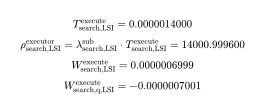

In [4]:
data_cardinality_per_replicaset = replicaset.data_cardinality_per_replicaset(
    MATH_MODEL_INPUT.data_cardinality, MATH_MODEL_INPUT.replicaset_count
)
pk_per_fk_per_cardinality_per_replicaset = (
    replicaset.pk_per_fk_per_cardinality_per_replicaset(
        data_cardinality_per_replicaset, MATH_MODEL_INPUT.fk_cardinality
    )
)

time_execute_search_LSI = executor.time_execute_search_LSI(
    data_cardinality_per_replicaset,
    MATH_MODEL_INPUT.btree_order,
    pk_per_fk_per_cardinality_per_replicaset,
    MATH_MODEL_INPUT.cpu_frequency,
    MATH_MODEL_INPUT.mem_frequency,
)

subintensity_search_LSI = MATH_MODEL_INPUT.intensity_search_LSI
load_executor_search_LSI = executor.load(
    subintensity_search_LSI, time_execute_search_LSI
)

queue_length_execute_search_LSI = (
    executor.pollaczek_khinchin_deterministic_queue_length(
        subintensity_search_LSI, time_execute_search_LSI
    )
)
service_time_execute_search_LSI = executor.littles_law_deterministic(
    queue_length_execute_search_LSI, subintensity_search_LSI
)
queue_time_execute_search_LSI = executor.queue_time_deterministic(
    service_time_execute_search_LSI, time_execute_search_LSI
)

res = rf"""
$#time_execute_search_LSI = "{time_execute_search_LSI:.10f}"$

$#load_executor_search_LSI = #subintensity_search_LSI dot #time_execute_search_LSI = {load_executor_search_LSI:5f}$

$#service_time_execute_search_LSI = {service_time_execute_search_LSI:.10f}$

$#queue_time_execute_search_LSI = {queue_time_execute_search_LSI:.10f}$
"""
output(res)

Рассчитаем время работы координатора и общее время ожидания пользователя

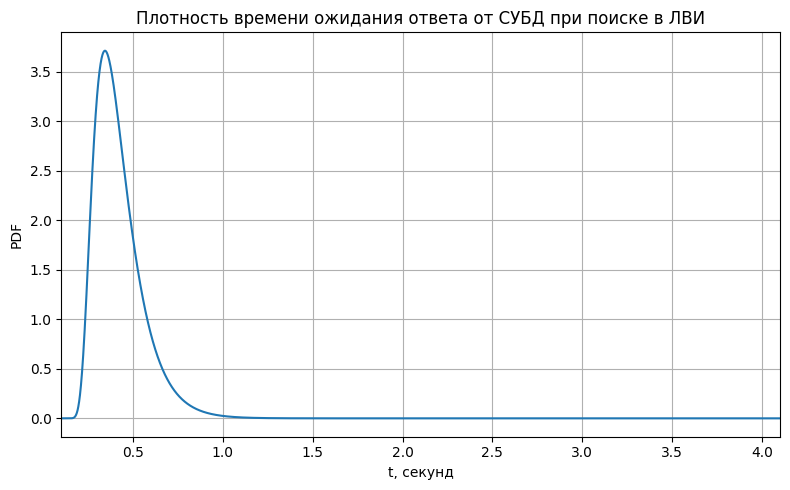

In [5]:
exec_plan_size = replicaset.exec_plan_size(MATH_MODEL_INPUT.row_size)
query_size = replicaset.query_size(MATH_MODEL_INPUT.row_size)

deterministic_part_of_tcsi_search_LSI = (
    exec_plan_size
    + MATH_MODEL_INPUT.row_size * pk_per_fk_per_cardinality_per_replicaset
) / MATH_MODEL_INPUT.cluster_net_speed


cluster_time_theta, cluster_time_k = (
    MATH_MODEL_INPUT.cluster_time_theta,
    MATH_MODEL_INPUT.cluster_time_k,
)
user_time_theta, user_time_k = (
    MATH_MODEL_INPUT.user_time_theta,
    MATH_MODEL_INPUT.user_time_k,
)

# общая сетка для СВ
x_grid = np.linspace(0, 2, 3000)

time_cluster_request_response_i_pdf = gamma_dist.pdf(
    x_grid, scale=cluster_time_theta * 2, a=cluster_time_k
)
time_cluster_request_response_i_cdf = gamma_dist.cdf(
    x_grid, scale=cluster_time_theta * 2, a=cluster_time_k
)
rv_i = helpers.RV(
    x_grid, time_cluster_request_response_i_pdf, time_cluster_request_response_i_cdf
).shift(deterministic_part_of_tcsi_search_LSI)

rv_max = helpers.RV.maximum(rv_i, rv_i)
for i in range(MATH_MODEL_INPUT.replicaset_count - 2):
    rv_max = helpers.RV.maximum(rv_i, rv_max)

# добавляем гамма-распределение задержки координатора
time_user_request_response_pdf = gamma_dist.pdf(
    x_grid, a=user_time_k, scale=user_time_theta
)
time_user_request_response_cdf = gamma_dist.cdf(
    x_grid, a=user_time_k, scale=user_time_theta
)
rv_extra = helpers.RV(
    x_grid, time_user_request_response_pdf, time_user_request_response_cdf
)

deterministic_part_of_tus_new = (
    query_size
    + MATH_MODEL_INPUT.row_size
    * pk_per_fk_per_cardinality_per_replicaset
    * MATH_MODEL_INPUT.replicaset_count
) / MATH_MODEL_INPUT.user_net_speed

time_user_search_LSI = (rv_max + rv_extra).shift(deterministic_part_of_tus_new)

# рисуем
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(
    time_user_search_LSI.x,
    time_user_search_LSI.pdf,
    label="Плотность времени ожидания пользователя",
)
ax1.set_xlabel("t, секунд")
ax1.set_ylabel("PDF")
ax1.set_title("Плотность времени ожидания ответа от СУБД при поиске в ЛВИ")
ax1.grid(True)
ax1.set_xlim(time_user_search_LSI.x[0], time_user_search_LSI.x[-1])
fig.tight_layout()
plt.show()

#### Показатели эффективности

Максимальная нагрузка на систему, среднее время обслуживания заявки, среднее время ожидания заявки в очереди и вероятность необслуживания заявки

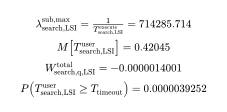

In [6]:
max_load_executor_search_LSI = 1 / time_execute_search_LSI
mean_time_user_search_LSI = time_user_search_LSI.mean()
prob_timeout_serach_LSI = user.prob_timeout(
    MATH_MODEL_INPUT.timeout,
    user_time_k,
    user_time_theta,
    cluster_time_k,
    cluster_time_theta,
    queue_time_execute_search_LSI,
    deterministic_part_of_tcsi_search_LSI,
    query_size,
    pk_per_fk_per_cardinality_per_replicaset,
    MATH_MODEL_INPUT.replicaset_count,
    MATH_MODEL_INPUT.row_size,
    MATH_MODEL_INPUT.user_net_speed,
)

res = rf"""
$#max_subintensity_search_LSI = 1 / #time_execute_search_LSI = {max_load_executor_search_LSI:.3f}$

$M[#time_user_search_LSI] = {mean_time_user_search_LSI:.5f}$

$#queue_time_total_search_LSI = {2 * queue_time_execute_search_LSI:.10f}$

$P(#time_user_search_LSI >= #timeout) = {prob_timeout_serach_LSI:.10f}$
"""
output(res)